In [1]:
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch

cloud_file = Path(
    "data/raw/satellite/ireland_clouds_20240101_20250101.npz"
)

with np.load(cloud_file) as data:
    times = data["times"]
    cloud_masks = data["cloud_mask"]
    heights = data["cth_km"]
    lat = data["lat"]
    lon = data["lon"]

print("Cloud masks:", cloud_masks.shape)
print("Cloud heights:", heights.shape)
print("First time:", times[0])
print("Last time:", times[-1])

Cloud masks: (8784, 90, 120)
Cloud heights: (8784, 90, 120)
First time: 2024-01-01T00:00:00.000000
Last time: 2024-12-31T23:00:00.000000


In [2]:
valid_pixels = np.count_nonzero(cloud_masks != 3, axis=(1, 2))

starts = np.arange(len(times) - 6)
sequence_positions = starts[:, None] + np.arange(6)
target_positions = starts + 6

usable = (
    (valid_pixels[sequence_positions] > 0).all(axis=1)
    & (valid_pixels[target_positions] > 0)
)

sequence_positions = sequence_positions[usable]
target_positions = target_positions[usable]

train_end = int(0.70 * len(times))
validation_end = int(0.85 * len(times))

train_rows = np.flatnonzero(target_positions < train_end)

validation_rows = np.flatnonzero(
    (target_positions >= train_end + 6)
    & (target_positions < validation_end)
)

test_rows = np.flatnonzero(
    target_positions >= validation_end + 6
)

for name, rows in [
    ("Training", train_rows),
    ("Validation", validation_rows),
    ("Test", test_rows),
]:
    print(
        f"{name}: {len(rows)} examples | "
        f"{times[target_positions[rows[0]]]} to "
        f"{times[target_positions[rows[-1]]]}"
    )

Training: 6104 examples | 2024-01-01T06:00:00.000000 to 2024-09-13T03:00:00.000000
Validation: 1312 examples | 2024-09-13T10:00:00.000000 to 2024-11-07T01:00:00.000000
Test: 1312 examples | 2024-11-07T08:00:00.000000 to 2024-12-31T23:00:00.000000


In [3]:
class CloudAndHeightDataset(Dataset):
    def __init__(self, rows):
        self.rows = rows

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, index):
        row = self.rows[index]
        input_positions = sequence_positions[row]
        target_position = target_positions[row]

        # Reduce 90 × 120 maps to 45 × 60, as before.
        input_masks = cloud_masks[input_positions, ::2, ::2]
        input_heights = heights[input_positions, ::2, ::2].astype(
            np.float32
        )

        input_cloud = (input_masks == 2).astype(np.float32)
        input_valid = (input_masks != 3).astype(np.float32)

        # Heights are useful as inputs only where clouds were observed.
        input_heights = np.nan_to_num(
            input_heights, nan=0.0, posinf=0.0, neginf=0.0
        )
        input_heights = (
            np.clip(input_heights, 0, 12) / 12
        ) * input_cloud

        images = np.stack(
            [input_cloud, input_heights, input_valid],
            axis=1
        ).astype(np.float32)

        target_mask = cloud_masks[target_position, ::2, ::2]
        raw_target_height = heights[
            target_position, ::2, ::2
        ].astype(np.float32)

        target_cloud = (target_mask == 2).astype(np.float32)
        valid_map = (target_mask != 3).astype(np.float32)

        height_valid = (
            (target_mask == 2)
            & np.isfinite(raw_target_height)
        ).astype(np.float32)

        target_height = np.nan_to_num(
            raw_target_height, nan=0.0, posinf=0.0, neginf=0.0
        )
        target_height = (
            np.clip(target_height, 0, 12) / 12
        ) * target_cloud

        return (
            torch.from_numpy(images),
            torch.from_numpy(target_cloud[None]),
            torch.from_numpy(target_height[None]),
            torch.from_numpy(valid_map[None]),
            torch.from_numpy(height_valid[None]),
        )


train_dataset = CloudAndHeightDataset(train_rows)
validation_dataset = CloudAndHeightDataset(validation_rows)
test_dataset = CloudAndHeightDataset(test_rows)

train_loader = DataLoader(
    train_dataset, batch_size=8, shuffle=True
)
validation_loader = DataLoader(
    validation_dataset, batch_size=8, shuffle=False
)
test_loader = DataLoader(
    test_dataset, batch_size=8, shuffle=False
)

images, cloud_target, height_target, valid_map, height_valid = (
    train_dataset[0]
)

print("Six input maps:", images.shape)
print("Cloud target:", cloud_target.shape)
print("Height target:", height_target.shape)

Six input maps: torch.Size([6, 3, 45, 60])
Cloud target: torch.Size([1, 45, 60])
Height target: torch.Size([1, 45, 60])


In [4]:
class CloudAndHeightModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, stride=2, padding=1),
            nn.ReLU(),
        )

        self.lstm = nn.LSTM(
            input_size=16,
            hidden_size=16,
            batch_first=True
        )

        self.decoder = nn.Sequential(
            nn.Upsample(
                size=(45, 60),
                mode="bilinear",
                align_corners=False
            ),
            nn.Conv2d(16, 16, kernel_size=3, padding=1),
            nn.ReLU(),
        )

        self.cloud_head = nn.Conv2d(16, 1, kernel_size=1)
        self.height_head = nn.Conv2d(16, 1, kernel_size=1)

    def forward(self, images):
        batch_size, hours, channels, height, width = images.shape

        x = images.reshape(
            batch_size * hours, channels, height, width
        )
        x = self.cnn(x)

        _, features, small_height, small_width = x.shape

        x = x.reshape(
            batch_size, hours, features, small_height, small_width
        )
        x = x.permute(0, 3, 4, 1, 2)
        x = x.reshape(
            batch_size * small_height * small_width,
            hours,
            features
        )

        x, _ = self.lstm(x)
        x = x[:, -1, :]

        x = x.reshape(
            batch_size, small_height, small_width, 16
        )
        x = x.permute(0, 3, 1, 2)
        x = self.decoder(x)

        # Start the cloud forecast from the last observed cloud map.
        last_cloud = images[:, -1, 0:1]
        cloud_scores = 4 * last_cloud - 2 + self.cloud_head(x)

        # Heights are normalized to the range 0–1.
        height_prediction = torch.sigmoid(self.height_head(x))

        return cloud_scores, height_prediction


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
map_model = CloudAndHeightModel().to(device)

with torch.no_grad():
    cloud_scores, height_prediction = map_model(
        images.unsqueeze(0).to(device)
    )

print("Cloud output:", cloud_scores.shape)
print("Height output:", height_prediction.shape)
print("Device:", device)

Cloud output: torch.Size([1, 1, 45, 60])
Height output: torch.Size([1, 1, 45, 60])
Device: cpu


In [5]:
def calculate_loss(
    cloud_scores,
    predicted_height,
    target_cloud,
    target_height,
    valid_map,
    height_valid,
):
    cloud_loss = F.binary_cross_entropy_with_logits(
        cloud_scores[valid_map.bool()],
        target_cloud[valid_map.bool()]
    )

    height_loss = F.smooth_l1_loss(
        predicted_height[height_valid.bool()],
        target_height[height_valid.bool()]
    )

    return cloud_loss + 5 * height_loss


def check_model(loader):
    map_model.eval()

    total_loss = 0
    intersection = 0
    union = 0
    height_error = 0
    height_count = 0

    with torch.no_grad():
        for batch in loader:
            images, target_cloud, target_height, valid, height_valid = (
                item.to(device) for item in batch
            )

            scores, predicted_height = map_model(images)

            loss = calculate_loss(
                scores, predicted_height,
                target_cloud, target_height,
                valid, height_valid
            )
            total_loss += loss.item() * len(images)

            predicted_cloud = torch.sigmoid(scores) >= 0.5
            actual_cloud = target_cloud.bool()
            valid_pixels = valid.bool()

            intersection += (
                predicted_cloud & actual_cloud & valid_pixels
            ).sum().item()

            union += (
                (predicted_cloud | actual_cloud) & valid_pixels
            ).sum().item()

            height_pixels = height_valid.bool()
            height_error += (
                torch.abs(
                    predicted_height[height_pixels]
                    - target_height[height_pixels]
                ).sum().item() * 12
            )
            height_count += height_pixels.sum().item()

    return (
        total_loss / len(loader.dataset),
        100 * intersection / union,
        height_error / height_count,
    )


optimizer = torch.optim.Adam(map_model.parameters(), lr=0.001)

models_folder = Path("models")
models_folder.mkdir(exist_ok=True)
model_file = models_folder / "best_cloud_and_height_model.pt"

best_validation_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, 13):
    map_model.train()
    training_loss = 0

    for batch in train_loader:
        images, target_cloud, target_height, valid, height_valid = (
            item.to(device) for item in batch
        )

        optimizer.zero_grad()

        scores, predicted_height = map_model(images)

        loss = calculate_loss(
            scores, predicted_height,
            target_cloud, target_height,
            valid, height_valid
        )

        loss.backward()
        optimizer.step()

        training_loss += loss.item() * len(images)

    training_loss /= len(train_dataset)

    validation_loss, validation_iou, validation_height_mae = (
        check_model(validation_loader)
    )

    print(
        f"Epoch {epoch:02d} | "
        f"Training loss: {training_loss:.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Cloud IoU: {validation_iou:.1f}% | "
        f"Height MAE: {validation_height_mae:.2f} km"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0
        torch.save(map_model.state_dict(), model_file)
        print("  Saved best model")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= 4:
        print("Stopped: validation loss has not improved for 4 epochs.")
        break

Epoch 01 | Training loss: 0.4489 | Validation loss: 0.4223 | Cloud IoU: 83.3% | Height MAE: 1.38 km
  Saved best model
Epoch 02 | Training loss: 0.4108 | Validation loss: 0.4219 | Cloud IoU: 83.1% | Height MAE: 1.34 km
  Saved best model
Epoch 03 | Training loss: 0.4054 | Validation loss: 0.4103 | Cloud IoU: 83.2% | Height MAE: 1.32 km
  Saved best model
Epoch 04 | Training loss: 0.4008 | Validation loss: 0.4075 | Cloud IoU: 83.5% | Height MAE: 1.26 km
  Saved best model
Epoch 05 | Training loss: 0.3962 | Validation loss: 0.4034 | Cloud IoU: 83.5% | Height MAE: 1.24 km
  Saved best model
Epoch 06 | Training loss: 0.3929 | Validation loss: 0.4003 | Cloud IoU: 83.6% | Height MAE: 1.30 km
  Saved best model
Epoch 07 | Training loss: 0.3908 | Validation loss: 0.3962 | Cloud IoU: 83.5% | Height MAE: 1.24 km
  Saved best model
Epoch 08 | Training loss: 0.3891 | Validation loss: 0.3959 | Cloud IoU: 83.4% | Height MAE: 1.22 km
  Saved best model
Epoch 09 | Training loss: 0.3876 | Validation lo

In [6]:
map_model.load_state_dict(
    torch.load(model_file, map_location=device, weights_only=True)
)
map_model.eval()

test_loss, test_iou, test_height_mae = check_model(test_loader)

print(f"Test cloud IoU: {test_iou:.1f}%")
print(f"Test cloud-height MAE: {test_height_mae:.2f} km")

Test cloud IoU: 84.6%
Test cloud-height MAE: 1.34 km


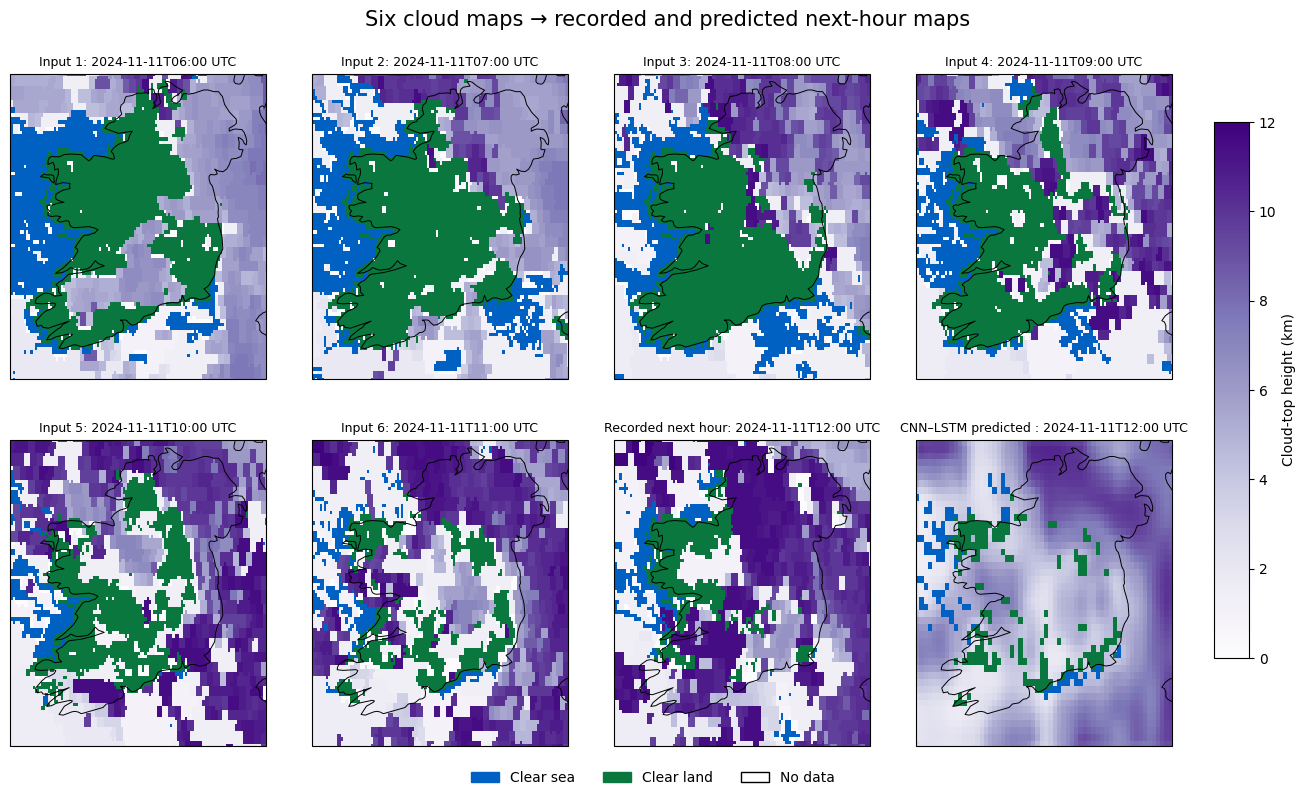

In [8]:
example_number = 100
example = test_rows[example_number]
input_positions = sequence_positions[example]
target_position = target_positions[example]
positions_to_show = list(input_positions) + [target_position]

images, _, _, _, _ = test_dataset[example_number]

with torch.no_grad():
    scores, predicted_height = map_model(
        images.unsqueeze(0).to(device)
    )

predicted_cloud = (
    torch.sigmoid(scores)[0, 0].cpu().numpy() >= 0.5
)
predicted_height = (
    predicted_height[0, 0].cpu().numpy() * 12
)

# Expand model outputs from 45 × 60 to 90 × 120 for plotting.
predicted_cloud = np.repeat(
    np.repeat(predicted_cloud, 2, axis=0), 2, axis=1
)
predicted_height = np.repeat(
    np.repeat(predicted_height, 2, axis=0), 2, axis=1
)

# Approximate the fixed land background from recorded clear-land pixels.
land = np.any(cloud_masks == 1, axis=0)
predicted_mask = np.where(land, 1, 0).astype(np.uint8)
predicted_mask[predicted_cloud] = 2
predicted_mask[cloud_masks[input_positions[-1]] == 3] = 3

background = ListedColormap([
    "#0161c2",  # clear sea
    "#09773e",  # clear land
    "#8e63b9",  # cloud beneath height layer
    "#ffffff",  # no data
])
norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    background.N
)

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.subplots_adjust(
    left=0.03, right=0.86, bottom=0.06, top=0.90,
    wspace=0.18, hspace=0.20
)

for panel, ax in enumerate(axes.flat):
    if panel < 7:
        position = positions_to_show[panel]
        mask = cloud_masks[position]
        height_map = heights[position].astype(np.float32)

        label = (
            f"Input {panel + 1}"
            if panel < 6
            else "Recorded next hour"
        )
        title_time = times[position]

    else:
        mask = predicted_mask
        height_map = predicted_height
        label = "CNN–LSTM predicted "
        title_time = times[target_position]

    ax.pcolormesh(
        lon, lat, mask,
        cmap=background,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    cloudy_heights = np.ma.masked_where(
        mask != 2, height_map
    )
    height_plot = ax.pcolormesh(
        lon, lat, cloudy_heights,
        cmap="Purples",
        vmin=0,
        vmax=12,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(
        resolution="50m",
        color="black",
        linewidth=0.7
    )
    ax.set_extent(
        [lon.min(), lon.max(), lat.min(), lat.max()],
        crs=ccrs.PlateCarree()
    )
    ax.set_aspect("auto")
    ax.set_title(
        f"{label}: {str(title_time)[:16]} UTC",
        fontsize=9
    )

fig.legend(
    handles=[
        Patch(color="#0161c2", label="Clear sea"),
        Patch(color="#09773e", label="Clear land"),
        Patch(facecolor="#ffffff", edgecolor="black", label="No data"),
    ],
    loc="lower center",
    ncol=3,
    frameon=False
)

colourbar_area = fig.add_axes([0.89, 0.17, 0.025, 0.67])
fig.colorbar(
    height_plot,
    cax=colourbar_area,
    label="Cloud-top height (km)"
)

fig.suptitle(
    "Six cloud maps → recorded and predicted next-hour maps",
    fontsize=15
)
plt.show()

In [12]:
# Continue training from the best saved model.
map_model.load_state_dict(
    torch.load(model_file, map_location=device, weights_only=True)
)

best_validation_loss, _, _ = check_model(validation_loader)
optimizer = torch.optim.Adam(map_model.parameters(), lr=0.00001)
epochs_without_improvement = 0

print(f"Starting validation loss: {best_validation_loss:.4f}")

for extra_epoch in range(1, 11):
    map_model.train()
    training_loss = 0

    for batch in train_loader:
        images, target_cloud, target_height, valid, height_valid = (
            item.to(device) for item in batch
        )

        optimizer.zero_grad()
        scores, predicted_height = map_model(images)

        loss = calculate_loss(
            scores, predicted_height,
            target_cloud, target_height,
            valid, height_valid
        )

        loss.backward()
        optimizer.step()
        training_loss += loss.item() * len(images)

    validation_loss, validation_iou, validation_height_mae = (
        check_model(validation_loader)
    )

    print(
        f"Extra epoch {extra_epoch:02d} | "
        f"Training loss: {training_loss / len(train_dataset):.4f} | "
        f"Validation loss: {validation_loss:.4f} | "
        f"Cloud IoU: {validation_iou:.1f}% | "
        f"Height MAE: {validation_height_mae:.2f} km"
    )

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        epochs_without_improvement = 0
        torch.save(map_model.state_dict(), model_file)
        print("  Saved improved model")
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= 3:
        print("Stopped: validation loss did not improve.")
        break

# Restore the best version before testing or plotting.
map_model.load_state_dict(
    torch.load(model_file, map_location=device, weights_only=True)
)
map_model.eval()

Starting validation loss: 0.3892
Extra epoch 01 | Training loss: 0.3815 | Validation loss: 0.3890 | Cloud IoU: 83.6% | Height MAE: 1.23 km
  Saved improved model
Extra epoch 02 | Training loss: 0.3815 | Validation loss: 0.3890 | Cloud IoU: 83.6% | Height MAE: 1.23 km
Extra epoch 03 | Training loss: 0.3815 | Validation loss: 0.3890 | Cloud IoU: 83.6% | Height MAE: 1.23 km
  Saved improved model
Extra epoch 04 | Training loss: 0.3815 | Validation loss: 0.3889 | Cloud IoU: 83.6% | Height MAE: 1.23 km
  Saved improved model
Extra epoch 05 | Training loss: 0.3815 | Validation loss: 0.3890 | Cloud IoU: 83.6% | Height MAE: 1.23 km
Extra epoch 06 | Training loss: 0.3814 | Validation loss: 0.3889 | Cloud IoU: 83.6% | Height MAE: 1.23 km
Extra epoch 07 | Training loss: 0.3814 | Validation loss: 0.3889 | Cloud IoU: 83.6% | Height MAE: 1.23 km
  Saved improved model
Extra epoch 08 | Training loss: 0.3815 | Validation loss: 0.3889 | Cloud IoU: 83.6% | Height MAE: 1.23 km
  Saved improved model
Extr

CloudAndHeightModel(
  (cnn): Sequential(
    (0): Conv2d(3, 8, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(8, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (lstm): LSTM(16, 16, batch_first=True)
  (decoder): Sequential(
    (0): Upsample(size=(45, 60), mode='bilinear')
    (1): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
  )
  (cloud_head): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
  (height_head): Conv2d(16, 1, kernel_size=(1, 1), stride=(1, 1))
)

In [13]:
map_model.load_state_dict(
    torch.load(model_file, map_location=device, weights_only=True)
)
map_model.eval()

test_loss, test_iou, test_height_mae = check_model(test_loader)

print(f"Test cloud IoU: {test_iou:.1f}%")
print(f"Test cloud-height MAE: {test_height_mae:.2f} km")

Test cloud IoU: 84.7%
Test cloud-height MAE: 1.33 km


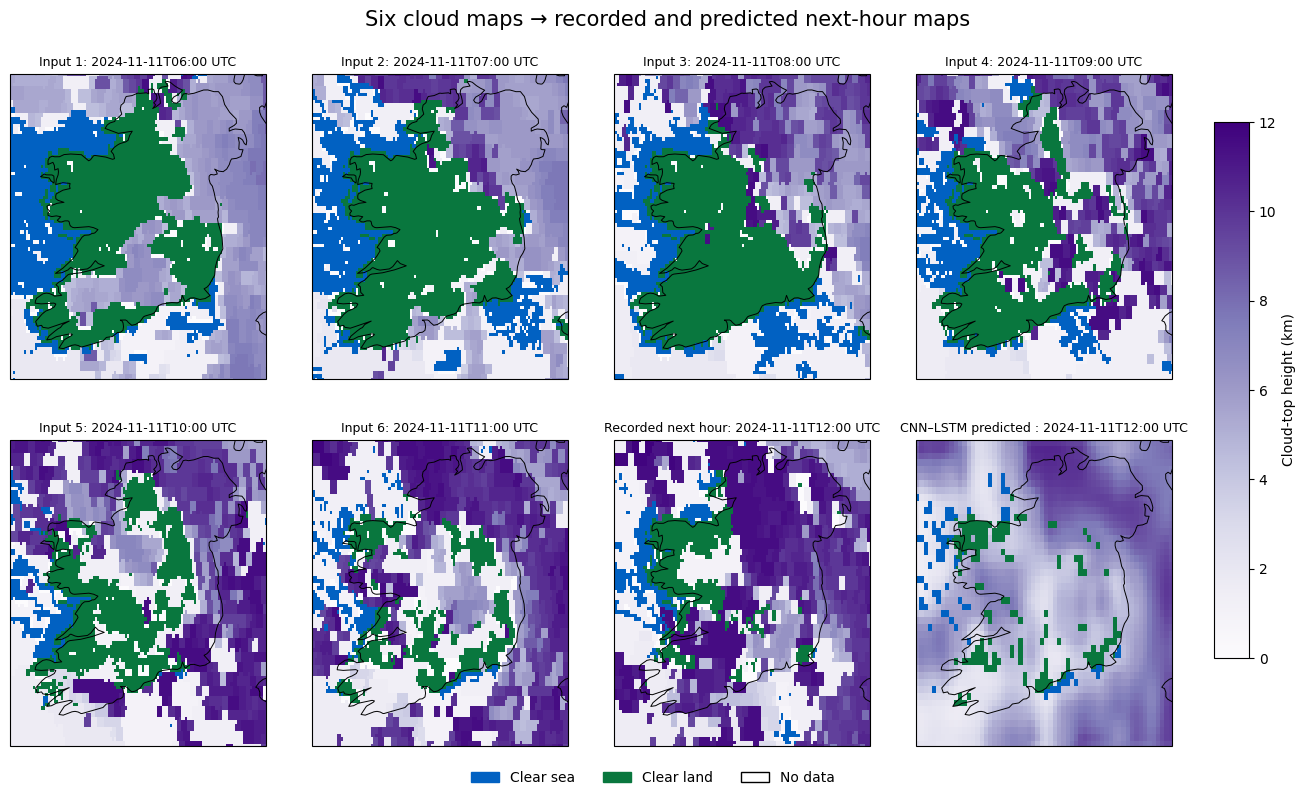

In [14]:
example_number = 100
example = test_rows[example_number]
input_positions = sequence_positions[example]
target_position = target_positions[example]
positions_to_show = list(input_positions) + [target_position]

images, _, _, _, _ = test_dataset[example_number]

with torch.no_grad():
    scores, predicted_height = map_model(
        images.unsqueeze(0).to(device)
    )

predicted_cloud = (
    torch.sigmoid(scores)[0, 0].cpu().numpy() >= 0.5
)
predicted_height = (
    predicted_height[0, 0].cpu().numpy() * 12
)

# Expand model outputs from 45 × 60 to 90 × 120 for plotting.
predicted_cloud = np.repeat(
    np.repeat(predicted_cloud, 2, axis=0), 2, axis=1
)
predicted_height = np.repeat(
    np.repeat(predicted_height, 2, axis=0), 2, axis=1
)

# Approximate the fixed land background from recorded clear-land pixels.
land = np.any(cloud_masks == 1, axis=0)
predicted_mask = np.where(land, 1, 0).astype(np.uint8)
predicted_mask[predicted_cloud] = 2
predicted_mask[cloud_masks[input_positions[-1]] == 3] = 3

background = ListedColormap([
    "#0161c2",  # clear sea
    "#09773e",  # clear land
    "#8e63b9",  # cloud beneath height layer
    "#ffffff",  # no data
])
norm = BoundaryNorm(
    [-0.5, 0.5, 1.5, 2.5, 3.5],
    background.N
)

fig, axes = plt.subplots(
    2, 4,
    figsize=(14, 8),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
fig.subplots_adjust(
    left=0.03, right=0.86, bottom=0.06, top=0.90,
    wspace=0.18, hspace=0.20
)

for panel, ax in enumerate(axes.flat):
    if panel < 7:
        position = positions_to_show[panel]
        mask = cloud_masks[position]
        height_map = heights[position].astype(np.float32)

        label = (
            f"Input {panel + 1}"
            if panel < 6
            else "Recorded next hour"
        )
        title_time = times[position]

    else:
        mask = predicted_mask
        height_map = predicted_height
        label = "CNN–LSTM predicted "
        title_time = times[target_position]

    ax.pcolormesh(
        lon, lat, mask,
        cmap=background,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    cloudy_heights = np.ma.masked_where(
        mask != 2, height_map
    )
    height_plot = ax.pcolormesh(
        lon, lat, cloudy_heights,
        cmap="Purples",
        vmin=0,
        vmax=12,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax.coastlines(
        resolution="50m",
        color="black",
        linewidth=0.7
    )
    ax.set_extent(
        [lon.min(), lon.max(), lat.min(), lat.max()],
        crs=ccrs.PlateCarree()
    )
    ax.set_aspect("auto")
    ax.set_title(
        f"{label}: {str(title_time)[:16]} UTC",
        fontsize=9
    )

fig.legend(
    handles=[
        Patch(color="#0161c2", label="Clear sea"),
        Patch(color="#09773e", label="Clear land"),
        Patch(facecolor="#ffffff", edgecolor="black", label="No data"),
    ],
    loc="lower center",
    ncol=3,
    frameon=False
)

colourbar_area = fig.add_axes([0.89, 0.17, 0.025, 0.67])
fig.colorbar(
    height_plot,
    cax=colourbar_area,
    label="Cloud-top height (km)"
)

fig.suptitle(
    "Six cloud maps → recorded and predicted next-hour maps",
    fontsize=15
)
plt.show()